# 🎯 Student Performance & Dropout Risk Prediction

## Tahap 2: Machine Learning Modeling

Pada tahap ini akan dilakukan pembangunan model machine learning untuk memprediksi risiko mahasiswa mengalami dropout. Beberapa algoritma klasifikasi akan dibandingkan untuk menentukan model dengan performa terbaik.

# 📚 Persiapan Lingkungan Machine Learning

Pada tahap ini dilakukan import berbagai library yang diperlukan untuk proses pemodelan machine learning.

Library yang digunakan mencakup:
- **Pandas** dan **NumPy** untuk manipulasi data.
- **Scikit-Learn** untuk preprocessing, pelatihan model, dan evaluasi performa.
- **Joblib** untuk menyimpan model terbaik yang nantinya akan digunakan pada aplikasi prediksi risiko dropout.

Persiapan library merupakan langkah awal yang penting untuk memastikan seluruh proses pemodelan dapat berjalan secara konsisten dan terstruktur.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Insight

Seluruh library berhasil dimuat dan siap digunakan untuk membangun model prediksi risiko dropout mahasiswa.

Tiga algoritma klasifikasi dipilih untuk dibandingkan, yaitu Logistic Regression, Decision Tree, dan Random Forest. Ketiga model tersebut memiliki karakteristik yang berbeda sehingga dapat memberikan gambaran mengenai algoritma yang paling efektif dalam memprediksi mahasiswa yang berisiko putus studi.

# 📂 Memuat Dataset

Dataset hasil tahap Exploratory Data Analysis (EDA) dimuat kembali untuk digunakan dalam proses pelatihan model machine learning.

Dataset ini berisi informasi demografis, akademik, dan finansial mahasiswa yang akan digunakan untuk memprediksi kemungkinan mahasiswa mengalami dropout.

In [2]:
df = pd.read_csv('dataset.csv')

### Insight

Dataset berhasil dimuat ke dalam lingkungan kerja dan siap diproses lebih lanjut.

Data yang digunakan mencakup berbagai faktor yang berpotensi memengaruhi keberhasilan studi mahasiswa, seperti usia saat masuk kuliah, status pembayaran kuliah, status beasiswa, performa akademik semester pertama, dan faktor sosial ekonomi lainnya.

# 🎯 Seleksi Fitur untuk Prediksi Dini

Tujuan utama proyek ini adalah mendeteksi risiko dropout sedini mungkin agar institusi pendidikan dapat melakukan intervensi sebelum mahasiswa benar-benar keluar dari perkuliahan.

Oleh karena itu, seluruh informasi yang berasal dari semester kedua dihapus dari dataset. Jika fitur semester kedua digunakan, model akan memperoleh informasi yang sebenarnya belum tersedia ketika prediksi awal dilakukan.

Langkah ini dilakukan untuk menghindari **data leakage** dan membuat model lebih realistis ketika diterapkan di dunia nyata.

In [3]:
drop_cols = [
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)'
]

df = df.drop(columns=drop_cols)

### Insight

Fitur semester kedua berhasil dihapus sehingga model hanya menggunakan informasi yang tersedia pada tahap awal perjalanan akademik mahasiswa.

Pendekatan ini membuat sistem prediksi lebih relevan untuk kebutuhan institusi pendidikan, karena risiko dropout dapat dideteksi lebih cepat tanpa harus menunggu hasil akademik semester berikutnya.

# 🔄 Transformasi Variabel Target

Algoritma machine learning bekerja lebih optimal ketika variabel target direpresentasikan dalam bentuk numerik.

Pada proyek ini, tujuan utama adalah mendeteksi mahasiswa yang berisiko mengalami **dropout**. Oleh karena itu, status mahasiswa diubah menjadi klasifikasi biner:

- **1 = Dropout**
- **0 = Non-Dropout** (Graduate dan Enrolled)

Pendekatan ini memungkinkan model untuk fokus membedakan mahasiswa yang berisiko putus studi dan yang tidak.

In [4]:
df['Target'] = df['Target'].apply(
    lambda x: 1 if x == 'Dropout' else 0
)

### Insight

Variabel target berhasil dikonversi menjadi format numerik sehingga dapat digunakan oleh algoritma klasifikasi.

Transformasi ini juga membuat fokus penelitian menjadi lebih jelas, yaitu mengidentifikasi mahasiswa yang berisiko dropout sejak dini.

# 🎯 Menentukan Fitur dan Target

Dataset kemudian dipisahkan menjadi:

- **X (Features)** → seluruh faktor yang digunakan untuk melakukan prediksi.
- **y (Target)** → status dropout yang ingin diprediksi.

Pemisahan ini merupakan langkah standar dalam proses machine learning sebelum data dibagi menjadi data latih dan data uji.

In [5]:
X = df.drop('Target', axis=1)
y = df['Target']

### Insight

Model akan mempelajari hubungan antara berbagai faktor akademik, finansial, dan demografis mahasiswa terhadap kemungkinan mahasiswa mengalami dropout.

# ⚖️ Analisis Keseimbangan Kelas (Class Imbalance)

Sebelum melatih model, penting untuk memeriksa distribusi kelas target.

Jika jumlah mahasiswa dropout jauh lebih sedikit dibandingkan mahasiswa non-dropout, model berpotensi bias terhadap kelas mayoritas dan mengabaikan mahasiswa yang sebenarnya berisiko.

Oleh karena itu dilakukan pemeriksaan keseimbangan kelas untuk menentukan apakah diperlukan penyesuaian seperti penggunaan **class_weight='balanced'** pada model.

In [6]:
class_counts = y.value_counts()
class_ratio  = y.value_counts(normalize=True) * 100

print("Distribusi Target:")
print(f"  Non-Dropout (0) : {class_counts[0]:>5}  ({class_ratio[0]:.1f}%)")
print(f"  Dropout     (1) : {class_counts[1]:>5}  ({class_ratio[1]:.1f}%)")

minority_ratio = class_ratio.min()
if minority_ratio < 35:
    print(f"\nData IMBALANCED (kelas minoritas hanya {minority_ratio:.1f}%)")
    print("   → Semua model akan menggunakan class_weight='balanced'")
    USE_CLASS_WEIGHT = True
else:
    print(f"\nData cukup seimbang ({minority_ratio:.1f}% vs {100-minority_ratio:.1f}%)")
    print("   → class_weight tidak diperlukan")
    USE_CLASS_WEIGHT = False

Distribusi Target:
  Non-Dropout (0) :  3003  (67.9%)
  Dropout     (1) :  1421  (32.1%)

Data IMBALANCED (kelas minoritas hanya 32.1%)
   → Semua model akan menggunakan class_weight='balanced'


### Insight

Distribusi target menunjukkan bahwa sekitar **32,1% mahasiswa mengalami dropout**, sedangkan **67,9% lainnya tidak mengalami dropout**.

Meskipun proporsinya tidak terlalu ekstrem, kelas dropout tetap merupakan kelas minoritas sehingga perlu mendapat perhatian khusus selama proses pelatihan model.

Untuk mengurangi potensi bias terhadap kelas mayoritas, seluruh model akan menggunakan parameter **class_weight='balanced'** agar kemampuan mendeteksi mahasiswa berisiko dropout tetap optimal.

# ✂️ Membagi Dataset Menjadi Data Latih dan Data Uji

Sebelum model dilatih, dataset perlu dibagi menjadi dua bagian:

- **Data Latih (Training Set)** digunakan untuk mempelajari pola hubungan antara karakteristik mahasiswa dan risiko dropout.
- **Data Uji (Testing Set)** digunakan untuk mengukur kemampuan model dalam melakukan prediksi pada data yang belum pernah dilihat sebelumnya.

Pada penelitian ini digunakan proporsi **80% data latih** dan **20% data uji**.

Selain itu, digunakan teknik **stratified sampling** untuk memastikan distribusi mahasiswa dropout dan non-dropout tetap proporsional pada kedua subset data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print("Ukuran Data Latih :", X_train.shape)
print("Ukuran Data Uji   :", X_test.shape)

Ukuran Data Latih : (3539, 28)
Ukuran Data Uji   : (885, 28)


### Insight

Dataset berhasil dibagi menjadi data latih dan data uji dengan proporsi 80:20.

Pendekatan ini memungkinkan model dipelajari menggunakan sebagian besar data yang tersedia, sekaligus menyediakan data independen untuk mengevaluasi performa model secara objektif.

Penggunaan stratified sampling juga memastikan bahwa proporsi mahasiswa dropout dan non-dropout tetap terjaga, sehingga hasil evaluasi lebih representatif terhadap kondisi dataset sebenarnya.

In [19]:
print("Distribusi Target pada Data Latih:")
print(y_train.value_counts(normalize=True)*100)

print("\nDistribusi Target pada Data Uji:")
print(y_test.value_counts(normalize=True)*100)

Distribusi Target pada Data Latih:
Target
0    67.87228
1    32.12772
Name: proportion, dtype: float64

Distribusi Target pada Data Uji:
Target
0    67.909605
1    32.090395
Name: proportion, dtype: float64


## ✅ Validasi Stratified Sampling

Hasil distribusi menunjukkan bahwa proporsi mahasiswa non-dropout pada data latih sebesar **67,87%** dan pada data uji sebesar **67,91%**. Sementara itu, proporsi mahasiswa dropout pada data latih sebesar **32,13%** dan pada data uji sebesar **32,09%**.

Perbedaan yang sangat kecil ini menunjukkan bahwa proses **stratified sampling** berhasil mempertahankan distribusi kelas asli dataset.

Dengan demikian, data latih dan data uji memiliki karakteristik yang serupa sehingga proses evaluasi model dapat dilakukan secara lebih adil, stabil, dan representatif terhadap kondisi data sebenarnya.

# 🤖 Pelatihan dan Perbandingan Algoritma Machine Learning

Pada penelitian ini digunakan tiga algoritma klasifikasi yang populer dan banyak digunakan dalam masalah prediksi risiko:

1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**

Ketiga model dipilih karena memiliki pendekatan yang berbeda dalam mempelajari pola data.

Dengan membandingkan beberapa algoritma, diharapkan dapat ditemukan model yang paling efektif dalam mengidentifikasi mahasiswa yang berisiko mengalami dropout.

## 📈 Logistic Regression

Logistic Regression merupakan algoritma klasifikasi yang sederhana namun kuat untuk memprediksi probabilitas suatu kejadian.

Pada penelitian ini, Logistic Regression digunakan sebagai baseline model untuk mengetahui seberapa baik hubungan antara karakteristik mahasiswa dan risiko dropout dapat dipelajari menggunakan model linear.

In [8]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        max_iter=1000,
        class_weight='balanced' if USE_CLASS_WEIGHT else None,
        random_state=42
    ))
])

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression selesai dilatih")

Logistic Regression selesai dilatih


### Insight

Model Logistic Regression berhasil dilatih menggunakan data latih dan menghasilkan prediksi pada data uji.

Model ini akan digunakan sebagai acuan awal (baseline) untuk dibandingkan dengan algoritma yang lebih kompleks pada tahap berikutnya.

## 🌳 Decision Tree

Decision Tree bekerja dengan membangun struktur pohon keputusan berdasarkan fitur-fitur yang dianggap paling informatif.

Keunggulan algoritma ini adalah kemampuannya menghasilkan aturan keputusan yang mudah dipahami dan diinterpretasikan.

In [9]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced' if USE_CLASS_WEIGHT else None
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree selesai dilatih")

Decision Tree selesai dilatih


### Insight

Decision Tree berhasil membangun aturan keputusan berdasarkan karakteristik mahasiswa.

Model ini diharapkan mampu menangkap hubungan yang lebih kompleks dibandingkan Logistic Regression.

## 🌲 Random Forest

Random Forest merupakan pengembangan dari Decision Tree yang menggabungkan banyak pohon keputusan untuk menghasilkan prediksi yang lebih stabil dan akurat.

Algoritma ini sering digunakan pada berbagai kompetisi data science karena mampu menangani data kompleks serta mengurangi risiko overfitting.

In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced' if USE_CLASS_WEIGHT else None
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest selesai dilatih")

Random Forest selesai dilatih


### Insight

Random Forest berhasil dilatih menggunakan 100 pohon keputusan yang bekerja secara kolektif untuk melakukan prediksi.

Pendekatan ensemble seperti ini umumnya mampu memberikan performa yang lebih baik dibandingkan model tunggal karena dapat mengurangi kesalahan prediksi pada masing-masing pohon.

# 📊 Perbandingan Performa Model

Setelah seluruh model selesai dilatih, langkah berikutnya adalah mengevaluasi kemampuan masing-masing model dalam mendeteksi mahasiswa yang berisiko mengalami dropout.

Evaluasi dilakukan menggunakan empat metrik utama:

- **Accuracy** → Persentase prediksi yang benar secara keseluruhan.
- **Precision** → Kemampuan model mengurangi false alarm (mahasiswa diprediksi dropout padahal sebenarnya tidak).
- **Recall** → Kemampuan model menemukan mahasiswa yang benar-benar berisiko dropout.
- **F1-Score** → Nilai keseimbangan antara Precision dan Recall.

Karena tujuan utama proyek ini adalah mendeteksi mahasiswa berisiko dropout sedini mungkin, metrik Recall dan F1-Score menjadi perhatian utama dalam pemilihan model terbaik.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_true, y_pred):

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

In [12]:
results = pd.DataFrame({
    'Logistic Regression': evaluate_model(y_test, y_pred_lr),
    'Decision Tree': evaluate_model(y_test, y_pred_dt),
    'Random Forest': evaluate_model(y_test, y_pred_rf)
}).T

results

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.863277,0.776271,0.806338,0.791019
Decision Tree,0.800000,0.682594,0.704225,0.693241
Random Forest,0.862147,0.855263,0.686620,0.761719


## 📌 Insight Hasil Evaluasi

Hasil evaluasi menunjukkan bahwa setiap model memiliki karakteristik yang berbeda.

### Logistic Regression
- Accuracy tertinggi (86.33%)
- Recall tertinggi (80.63%)
- F1-Score tertinggi (79.10%)

Model ini paling baik dalam menemukan mahasiswa yang benar-benar berisiko dropout.

### Random Forest
- Precision tertinggi (85.53%)

Model ini lebih berhati-hati dalam memberikan prediksi dropout sehingga menghasilkan false positive yang lebih sedikit.

### Decision Tree
- Performa terendah pada hampir seluruh metrik evaluasi.

Model ini mampu menangkap pola data, namun belum sebaik Logistic Regression maupun Random Forest.

### Kesimpulan Sementara

Pada tahap evaluasi awal, **Logistic Regression menunjukkan performa paling seimbang** dengan kombinasi Accuracy, Recall, dan F1-Score tertinggi.

Karena tujuan utama proyek adalah mengidentifikasi mahasiswa yang berisiko dropout sedini mungkin, maka kemampuan Recall yang tinggi menjadi sangat penting. Oleh karena itu Logistic Regression menjadi kandidat kuat sebagai model terbaik.

# 📋 Classification Report

Selain metrik evaluasi secara keseluruhan, diperlukan analisis yang lebih rinci untuk melihat performa masing-masing model pada setiap kelas target.

Pada proyek ini:

- Kelas 0 = Non-Dropout
- Kelas 1 = Dropout

Classification Report digunakan untuk mengevaluasi kemampuan model dalam mengidentifikasi mahasiswa yang berisiko dropout maupun yang tidak berisiko dropout melalui metrik:

- **Precision** → Seberapa akurat prediksi suatu kelas.
- **Recall** → Seberapa banyak data pada suatu kelas yang berhasil dikenali model.
- **F1-Score** → Keseimbangan antara Precision dan Recall.
- **Support** → Jumlah data pada masing-masing kelas.

Karena tujuan utama proyek adalah mendeteksi mahasiswa yang berisiko dropout sedini mungkin, perhatian khusus diberikan pada nilai **Recall** dan **F1-Score** untuk kelas Dropout.

In [20]:
reports = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree':       y_pred_dt,
    'Random Forest':       y_pred_rf
}

for nama_model, y_pred in reports.items():
    print(f"{'='*50}")
    print(f"  {nama_model}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Non-Dropout', 'Dropout']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.89      0.90       601
     Dropout       0.78      0.81      0.79       284

    accuracy                           0.86       885
   macro avg       0.84      0.85      0.84       885
weighted avg       0.86      0.86      0.86       885


  Decision Tree
              precision    recall  f1-score   support

 Non-Dropout       0.86      0.85      0.85       601
     Dropout       0.68      0.70      0.69       284

    accuracy                           0.80       885
   macro avg       0.77      0.77      0.77       885
weighted avg       0.80      0.80      0.80       885


  Random Forest
              precision    recall  f1-score   support

 Non-Dropout       0.86      0.95      0.90       601
     Dropout       0.86      0.69      0.76       284

    accuracy                           0.86       885
   macro avg       0.86      0.82      0.83       885
weighted avg      

# 📌 Insight Classification Report

Hasil evaluasi menunjukkan bahwa ketiga model mampu mengidentifikasi mahasiswa non-dropout dengan performa yang cukup baik.

Namun, ketika fokus diarahkan pada kelas **Dropout**, terdapat perbedaan performa yang cukup signifikan antar model:

- **Logistic Regression** memperoleh Recall Dropout sebesar **81%**, tertinggi di antara seluruh model.
- **Decision Tree** memperoleh Recall Dropout sebesar **70%**.
- **Random Forest** memperoleh Recall Dropout sebesar **69%**.

Hal ini menunjukkan bahwa Logistic Regression mampu mendeteksi lebih banyak mahasiswa yang benar-benar berisiko dropout dibandingkan model lainnya.

Selain itu, Logistic Regression juga menghasilkan **F1-Score tertinggi (79%)**, yang menunjukkan keseimbangan terbaik antara Precision dan Recall.

### Kesimpulan

Berdasarkan Classification Report, **Logistic Regression** merupakan model yang paling sesuai untuk digunakan dalam sistem prediksi risiko dropout mahasiswa karena mampu mendeteksi lebih banyak kasus dropout tanpa mengorbankan akurasi secara signifikan.

# 🔍 Analisis Faktor yang Paling Berpengaruh

Setelah model berhasil dilatih, langkah berikutnya adalah mengidentifikasi fitur-fitur yang paling berkontribusi dalam proses prediksi.

Analisis Feature Importance digunakan untuk mengetahui faktor apa saja yang paling berpengaruh terhadap risiko mahasiswa mengalami dropout.

In [14]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
22,Curricular units 1st sem (approved),0.185873
23,Curricular units 1st sem (grade),0.134278
14,Tuition fees up to date,0.072381
17,Age at enrollment,0.067305
21,Curricular units 1st sem (evaluations),0.053008
3,Course,0.048215
10,Father's occupation,0.042290
9,Mother's occupation,0.038598
8,Father's qualification,0.031635
1,Application mode,0.031587


## 📌 Insight Feature Importance

Hasil analisis menunjukkan bahwa performa akademik pada semester pertama merupakan faktor yang paling berpengaruh dalam memprediksi risiko dropout.

Tiga faktor teratas yang ditemukan model adalah:

1. **Curricular units 1st sem (approved)**
2. **Curricular units 1st sem (grade)**
3. **Tuition fees up to date**

Temuan ini menunjukkan bahwa mahasiswa yang memiliki jumlah mata kuliah lulus lebih sedikit, nilai akademik yang rendah, serta memiliki kendala pembayaran kuliah cenderung memiliki risiko dropout yang lebih tinggi.

Selain faktor akademik, variabel seperti usia saat masuk kuliah (*Age at enrollment*) dan latar belakang keluarga juga turut memberikan kontribusi terhadap prediksi model.

### Kesimpulan

Faktor akademik pada semester pertama terbukti menjadi indikator paling kuat dalam mendeteksi risiko dropout. Oleh karena itu, institusi pendidikan dapat memanfaatkan informasi tersebut untuk melakukan intervensi lebih dini kepada mahasiswa yang menunjukkan penurunan performa akademik sejak semester awal.

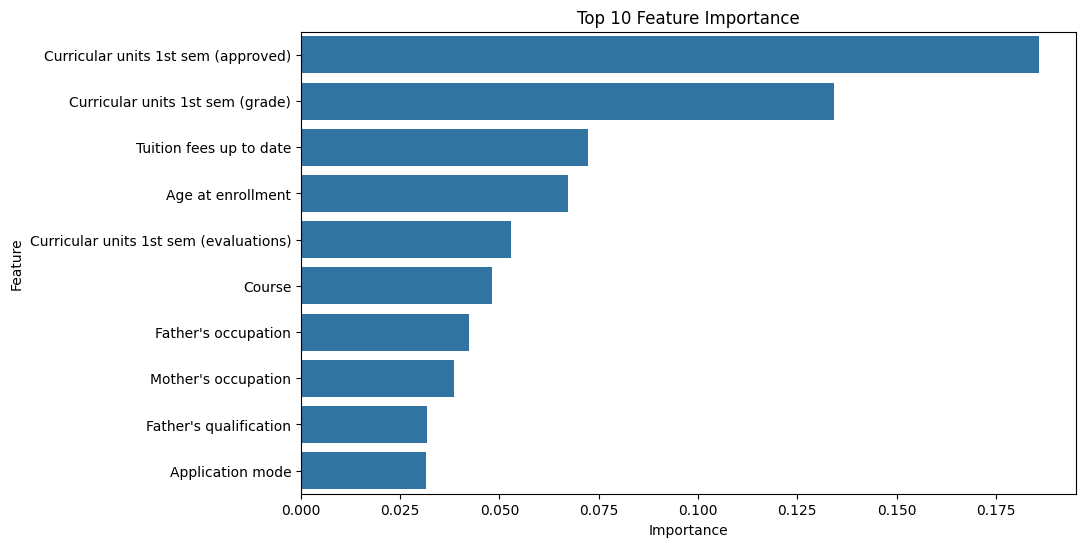

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance')
plt.show()

## 📌 Insight Top 10 Feature Importance

Grafik di atas menunjukkan 10 fitur yang paling berpengaruh dalam proses prediksi risiko dropout berdasarkan model Random Forest.

Terlihat bahwa faktor akademik pada semester pertama mendominasi posisi teratas, terutama:

1. **Curricular units 1st sem (approved)**
2. **Curricular units 1st sem (grade)**
3. **Tuition fees up to date**
4. **Age at enrollment**

Hal ini menunjukkan bahwa performa mahasiswa pada semester awal memiliki hubungan yang sangat kuat terhadap keberhasilan studi di masa mendatang.

Mahasiswa yang memiliki jumlah mata kuliah lulus lebih sedikit dan nilai semester pertama yang rendah cenderung memiliki risiko dropout yang lebih tinggi dibandingkan mahasiswa dengan performa akademik yang baik.

Selain faktor akademik, kondisi administrasi seperti status pembayaran kuliah (**Tuition fees up to date**) juga muncul sebagai faktor penting. Temuan ini sejalan dengan hasil EDA sebelumnya yang menunjukkan bahwa mahasiswa yang memiliki tunggakan pembayaran lebih rentan mengalami dropout.

Usia saat pertama kali masuk kuliah (**Age at enrollment**) juga memberikan pengaruh yang cukup besar. Mahasiswa yang masuk pada usia lebih tinggi cenderung memiliki tantangan tambahan yang dapat memengaruhi keberlangsungan studi.

### Kesimpulan

Berdasarkan hasil analisis feature importance, faktor akademik semester pertama merupakan indikator paling kuat dalam mendeteksi risiko dropout mahasiswa. Oleh karena itu, institusi pendidikan dapat memanfaatkan informasi nilai, jumlah mata kuliah lulus, dan status pembayaran kuliah sebagai sistem peringatan dini (early warning system) untuk mengidentifikasi mahasiswa yang membutuhkan pendampingan akademik lebih awal.

# 🏆 Pemilihan Model Terbaik

Setelah seluruh model dievaluasi, langkah berikutnya adalah memilih model terbaik yang akan digunakan pada aplikasi prediksi.

Pemilihan model dilakukan berdasarkan nilai **F1-Score**, karena metrik ini mempertimbangkan keseimbangan antara Precision dan Recall.

Pada kasus prediksi dropout, F1-Score lebih relevan dibanding Accuracy karena dataset memiliki distribusi kelas yang tidak sepenuhnya seimbang.

In [16]:
best_model_name = results['F1-Score'].idxmax()
best_f1         = results.loc[best_model_name, 'F1-Score']
best_accuracy   = results.loc[best_model_name, 'Accuracy']

print("Perbandingan Semua Model:")
print(results.to_string())
print()
print(f"Model Terbaik   : {best_model_name}")
print(f"   F1-Score        : {best_f1:.4f}")
print(f"   Accuracy        : {best_accuracy:.4f}")

model_map = {
    'Logistic Regression': lr,
    'Decision Tree':       dt,
    'Random Forest':       rf
}

best_model = model_map[best_model_name]
print(f"\n'{best_model_name}' siap disimpan.")

Perbandingan Semua Model:
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.863277   0.776271  0.806338  0.791019
Decision Tree        0.800000   0.682594  0.704225  0.693241
Random Forest        0.862147   0.855263  0.686620  0.761719

Model Terbaik   : Logistic Regression
   F1-Score        : 0.7910
   Accuracy        : 0.8633

'Logistic Regression' siap disimpan.


## 📌 Hasil Pemilihan Model

Berdasarkan hasil evaluasi, **Logistic Regression** memperoleh F1-Score tertinggi sebesar **0.7910** dengan Accuracy sebesar **86.33%**.

Meskipun Random Forest memiliki Precision yang lebih tinggi, Logistic Regression menunjukkan keseimbangan yang lebih baik antara Precision dan Recall sehingga lebih efektif dalam mendeteksi mahasiswa yang berisiko dropout.

### Kesimpulan

Logistic Regression dipilih sebagai model terbaik dan akan digunakan pada tahap deployment aplikasi karena memiliki performa paling stabil dalam memprediksi risiko dropout mahasiswa.

# 💾 Menyimpan Model

Model terbaik yang telah dipilih perlu disimpan agar dapat digunakan kembali tanpa perlu melakukan proses training ulang.

Pada tahap ini model disimpan dalam format `.joblib`, sehingga nantinya dapat langsung dipanggil oleh aplikasi Streamlit untuk melakukan prediksi secara real-time.

In [17]:
os.makedirs('models', exist_ok=True)

best_model_path = 'models/best_model.joblib'
joblib.dump(best_model, best_model_path)
print(f"Model terbaik disimpan  : {best_model_path}")
print(f"   ({best_model_name})")

joblib.dump(lr, 'models/logistic_regression.joblib')
joblib.dump(dt, 'models/decision_tree.joblib')
joblib.dump(rf, 'models/random_forest.joblib')
print("\nSemua model tersimpan di folder models/:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"   └── {f:<35} ({size:.1f} KB)")

Model terbaik disimpan  : models/best_model.joblib
   (Logistic Regression)

Semua model tersimpan di folder models/:
   └── decision_tree.joblib                (95.2 KB)
   └── random_forest.joblib                (8963.2 KB)
   └── best_model.joblib                   (3.1 KB)
   └── logistic_regression.joblib          (3.1 KB)


# 🎯 Kesimpulan Tahap Modeling

Pada tahap pemodelan machine learning, dilakukan pelatihan dan evaluasi menggunakan tiga algoritma klasifikasi, yaitu Logistic Regression, Decision Tree, dan Random Forest.

Hasil evaluasi menunjukkan bahwa Logistic Regression memberikan performa terbaik dengan:

- Accuracy : 86.33%
- Precision : 77.63%
- Recall : 80.63%
- F1-Score : 79.10%

Selain itu, analisis Feature Importance menunjukkan bahwa performa akademik pada semester pertama, jumlah mata kuliah yang lulus, status pembayaran kuliah, dan usia saat masuk kuliah merupakan faktor yang paling berpengaruh terhadap risiko dropout.

Model terbaik telah berhasil disimpan dan siap digunakan pada tahap berikutnya, yaitu pengembangan aplikasi prediksi menggunakan Streamlit.